## Import Required Libraries

In [2]:
# Import libraries for data handling and machine learning
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC  # Support Vector Machine (SVM)
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')


## Load and Inspect Dataset

In [4]:
# Load the dataset
data = pd.read_csv("Language Detection.csv")

# Display the first few rows of the dataset to understand its structure
print("Dataset Preview:")
print(data.head())

# Check dataset size and class distribution
print(f"\nDataset Size: {data.shape}")
print("\nClass Distribution:")
print(data['Language'].value_counts())


Dataset Preview:
                                                Text Language
0   Nature, in the broadest sense, is the natural...  English
1  "Nature" can refer to the phenomena of the phy...  English
2  The study of nature is a large, if not the onl...  English
3  Although humans are part of nature, human acti...  English
4  [1] The word nature is borrowed from the Old F...  English

Dataset Size: (10337, 2)

Class Distribution:
Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64


## Split Dataset into Training and Test Sets

In [6]:
# Separate features (Text) and target variable (Language)
X = data['Text']  # Feature: text data
y = data['Language']  # Target: language labels

# Split dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the size of the training and test sets
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 8269
Test set size: 2068


## Convert Text Data to TF-IDF Features

In [8]:
# Initialize the TF-IDF Vectorizer with a vocabulary size of 5000
tfidf = TfidfVectorizer(max_features=5000)

# Transform the training and test text data into TF-IDF feature vectors
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Print the shape of transformed feature sets
print(f"TF-IDF Transformed Training Set: {X_train_tfidf.shape}")
print(f"TF-IDF Transformed Test Set: {X_test_tfidf.shape}")


TF-IDF Transformed Training Set: (8269, 5000)
TF-IDF Transformed Test Set: (2068, 5000)


## Train and Test Multinomial Naive Bayes

In [10]:
# Initialize the Multinomial Naive Bayes model
model_nb = MultinomialNB()

# Train the model on the training set
model_nb.fit(X_train_tfidf, y_train)

# Predict the language for the test set
y_pred_nb = model_nb.predict(X_test_tfidf)

# Evaluate model performance
print("\nMultinomial Naive Bayes Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.2f}")
print(classification_report(y_test, y_pred_nb))



Multinomial Naive Bayes Performance:
Accuracy: 0.96
              precision    recall  f1-score   support

      Arabic       1.00      0.93      0.97       106
      Danish       1.00      0.89      0.94        73
       Dutch       0.99      0.95      0.97       111
     English       0.81      1.00      0.90       291
      French       0.96      0.98      0.97       219
      German       1.00      0.95      0.97        93
       Greek       1.00      0.93      0.96        68
       Hindi       1.00      0.70      0.82        10
     Italian       1.00      0.97      0.98       145
     Kannada       1.00      1.00      1.00        66
   Malayalam       1.00      0.98      0.99       121
  Portugeese       1.00      0.94      0.97       144
     Russian       0.99      0.93      0.96       136
     Spanish       0.96      0.97      0.97       160
    Sweedish       0.95      0.98      0.97       133
       Tamil       1.00      0.99      0.99        87
     Turkish       1.00     

## Train and Test Logistic Regression

In [12]:
# Initialize the Logistic Regression model
model_lr = LogisticRegression(max_iter=500)

# Train the model on the training set
model_lr.fit(X_train_tfidf, y_train)

# Predict the language for the test set
y_pred_lr = model_lr.predict(X_test_tfidf)

# Evaluate model performance
print("\nLogistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}")
print(classification_report(y_test, y_pred_lr))



Logistic Regression Performance:
Accuracy: 0.95
              precision    recall  f1-score   support

      Arabic       1.00      0.92      0.96       106
      Danish       0.96      0.90      0.93        73
       Dutch       1.00      0.92      0.96       111
     English       0.97      0.99      0.98       291
      French       0.97      0.98      0.97       219
      German       0.98      0.94      0.96        93
       Greek       1.00      0.91      0.95        68
       Hindi       1.00      0.70      0.82        10
     Italian       1.00      0.94      0.97       145
     Kannada       1.00      1.00      1.00        66
   Malayalam       1.00      0.98      0.99       121
  Portugeese       0.99      0.94      0.97       144
     Russian       0.70      1.00      0.82       136
     Spanish       0.92      0.97      0.95       160
    Sweedish       0.97      0.95      0.96       133
       Tamil       1.00      0.98      0.99        87
     Turkish       1.00      0.8

## Train and Test Decision Tree Classifier

In [14]:
# Initialize the Decision Tree Classifier
model_dt = DecisionTreeClassifier()

# Train the model on the training set
model_dt.fit(X_train_tfidf, y_train)

# Predict the language for the test set
y_pred_dt = model_dt.predict(X_test_tfidf)

# Evaluate model performance
print("\nDecision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print(classification_report(y_test, y_pred_dt))



Decision Tree Performance:
Accuracy: 0.88
              precision    recall  f1-score   support

      Arabic       1.00      0.90      0.95       106
      Danish       0.89      0.74      0.81        73
       Dutch       0.87      0.83      0.85       111
     English       0.96      0.96      0.96       291
      French       0.93      0.83      0.88       219
      German       0.92      0.86      0.89        93
       Greek       1.00      0.88      0.94        68
       Hindi       1.00      1.00      1.00        10
     Italian       0.96      0.88      0.92       145
     Kannada       1.00      0.91      0.95        66
   Malayalam       1.00      0.91      0.95       121
  Portugeese       0.95      0.84      0.89       144
     Russian       1.00      0.79      0.89       136
     Spanish       0.75      0.88      0.81       160
    Sweedish       0.89      0.89      0.89       133
       Tamil       1.00      0.95      0.98        87
     Turkish       0.44      0.94     

##  Train and Test Random Forest Classifier

In [16]:
# Initialize the Random Forest Classifier
model_rf = RandomForestClassifier(n_estimators=100)

# Train the model on the training set
model_rf.fit(X_train_tfidf, y_train)

# Predict the language for the test set
y_pred_rf = model_rf.predict(X_test_tfidf)

# Evaluate model performance
print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(classification_report(y_test, y_pred_rf))



Random Forest Performance:
Accuracy: 0.93
              precision    recall  f1-score   support

      Arabic       0.99      0.91      0.95       106
      Danish       0.93      0.85      0.89        73
       Dutch       1.00      0.88      0.94       111
     English       0.96      0.97      0.97       291
      French       0.96      0.94      0.95       219
      German       0.95      0.90      0.93        93
       Greek       1.00      0.91      0.95        68
       Hindi       1.00      1.00      1.00        10
     Italian       0.99      0.91      0.95       145
     Kannada       1.00      0.98      0.99        66
   Malayalam       1.00      0.97      0.98       121
  Portugeese       0.98      0.94      0.96       144
     Russian       1.00      0.90      0.95       136
     Spanish       0.88      0.95      0.91       160
    Sweedish       0.95      0.93      0.94       133
       Tamil       1.00      0.98      0.99        87
     Turkish       0.58      0.96     

## Train and Test Gradient Boosting Classifier

In [18]:
# Initialize the Gradient Boosting Classifier
model_gb = GradientBoostingClassifier()

# Train the model on the training set
model_gb.fit(X_train_tfidf, y_train)

# Predict the language for the test set
y_pred_gb = model_gb.predict(X_test_tfidf)

# Evaluate model performance
print("\nGradient Boosting Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.2f}")
print(classification_report(y_test, y_pred_gb))



Gradient Boosting Performance:
Accuracy: 0.91
              precision    recall  f1-score   support

      Arabic       1.00      0.89      0.94       106
      Danish       0.90      0.85      0.87        73
       Dutch       0.99      0.86      0.92       111
     English       0.97      0.96      0.96       291
      French       0.95      0.94      0.94       219
      German       0.99      0.90      0.94        93
       Greek       1.00      0.85      0.92        68
       Hindi       1.00      0.50      0.67        10
     Italian       0.95      0.86      0.90       145
     Kannada       1.00      0.89      0.94        66
   Malayalam       1.00      0.93      0.96       121
  Portugeese       0.99      0.91      0.95       144
     Russian       0.53      0.99      0.69       136
     Spanish       0.84      0.92      0.88       160
    Sweedish       0.97      0.92      0.94       133
       Tamil       1.00      0.95      0.98        87
     Turkish       1.00      0.80 

## Train and Test SVM (Support Vector Machine)

In [20]:
# Initialize the SVM model
model_svm = SVC(kernel='linear')

# Train the model on the training set
model_svm.fit(X_train_tfidf, y_train)

# Predict the language for the test set
y_pred_svm = model_svm.predict(X_test_tfidf)

# Evaluate model performance
print("\nSVM Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print(classification_report(y_test, y_pred_svm))



SVM Performance:
Accuracy: 0.95
              precision    recall  f1-score   support

      Arabic       0.99      0.92      0.95       106
      Danish       0.96      0.90      0.93        73
       Dutch       1.00      0.93      0.96       111
     English       0.97      0.99      0.98       291
      French       0.99      0.97      0.98       219
      German       0.97      0.92      0.95        93
       Greek       1.00      0.91      0.95        68
       Hindi       1.00      0.80      0.89        10
     Italian       1.00      0.92      0.96       145
     Kannada       1.00      1.00      1.00        66
   Malayalam       1.00      0.97      0.98       121
  Portugeese       0.99      0.94      0.97       144
     Russian       0.67      1.00      0.80       136
     Spanish       0.93      0.96      0.94       160
    Sweedish       0.97      0.95      0.96       133
       Tamil       1.00      0.97      0.98        87
     Turkish       1.00      0.88      0.93     

## Train and Test MLP Classifier (Neural Network)

In [22]:
# Initialize the Multi-Layer Perceptron (MLP) Classifier
model_mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)

# Train the model on the training set
model_mlp.fit(X_train_tfidf, y_train)

# Predict the language for the test set
y_pred_mlp = model_mlp.predict(X_test_tfidf)

# Evaluate model performance
print("\nMLP Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.2f}")
print(classification_report(y_test, y_pred_mlp))



MLP Classifier Performance:
Accuracy: 0.96
              precision    recall  f1-score   support

      Arabic       1.00      0.93      0.97       106
      Danish       0.93      0.92      0.92        73
       Dutch       0.98      0.94      0.96       111
     English       0.99      0.99      0.99       291
      French       0.97      0.98      0.98       219
      German       0.98      0.96      0.97        93
       Greek       1.00      0.93      0.96        68
       Hindi       1.00      1.00      1.00        10
     Italian       0.98      0.94      0.96       145
     Kannada       1.00      1.00      1.00        66
   Malayalam       1.00      0.98      0.99       121
  Portugeese       0.99      0.94      0.96       144
     Russian       0.99      0.93      0.96       136
     Spanish       0.95      0.97      0.96       160
    Sweedish       0.98      0.97      0.98       133
       Tamil       1.00      0.99      0.99        87
     Turkish       0.69      0.97    

## Compare Model Accuracies

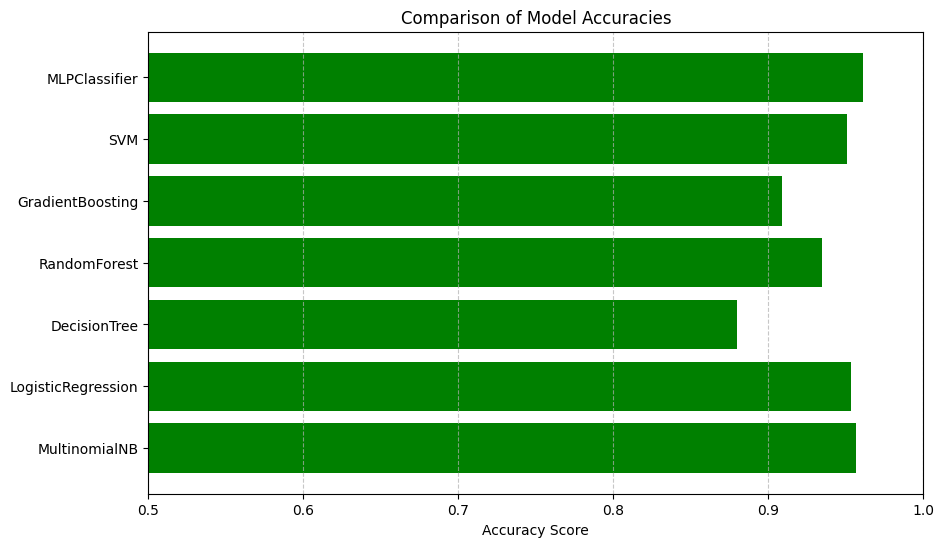

In [24]:
import matplotlib.pyplot as plt

# Collect the models' accuracy scores
model_names = ["MultinomialNB", "LogisticRegression", "DecisionTree", "RandomForest", "GradientBoosting", "SVM", "MLPClassifier"]
accuracies = [
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_mlp),
]

# Plot the accuracy scores for each model
plt.figure(figsize=(10, 6))
plt.barh(model_names, accuracies, color='green')
plt.xlabel('Accuracy Score')
plt.title('Comparison of Model Accuracies')
plt.xlim(0.5, 1)  # Adjust x-axis for better visualization
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## Plot Confusion Matrices


Confusion Matrix: MultinomialNB


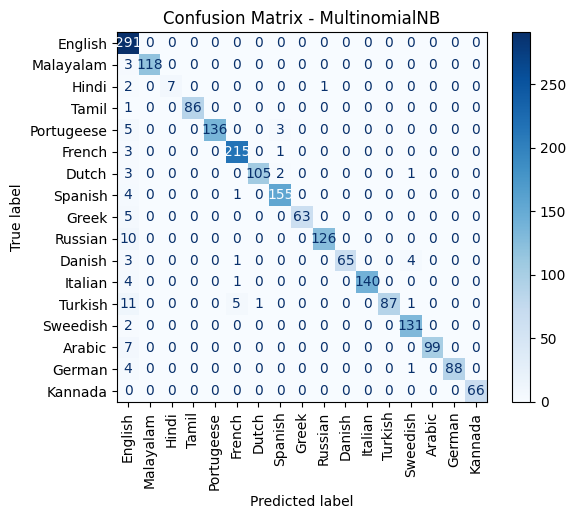


Confusion Matrix: LogisticRegression


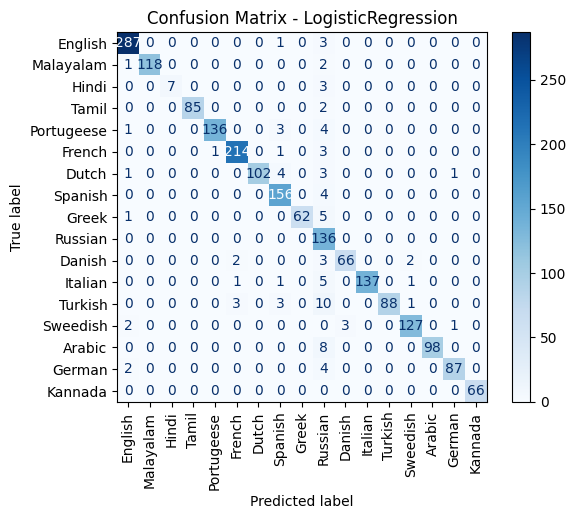


Confusion Matrix: DecisionTree


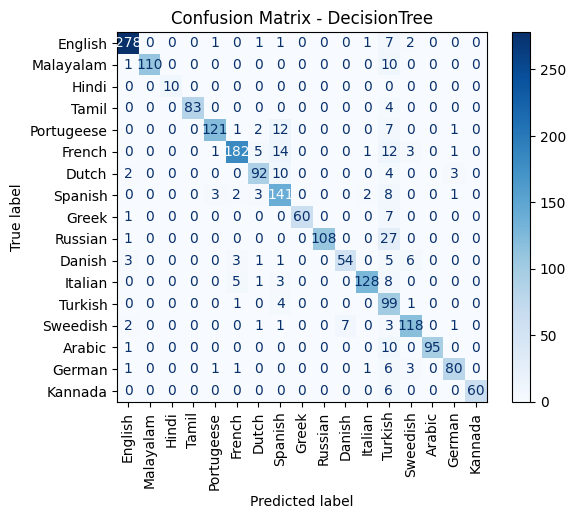


Confusion Matrix: RandomForest


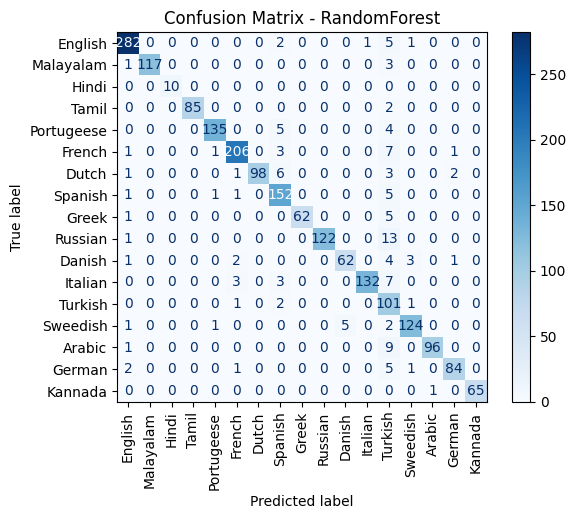


Confusion Matrix: GradientBoosting


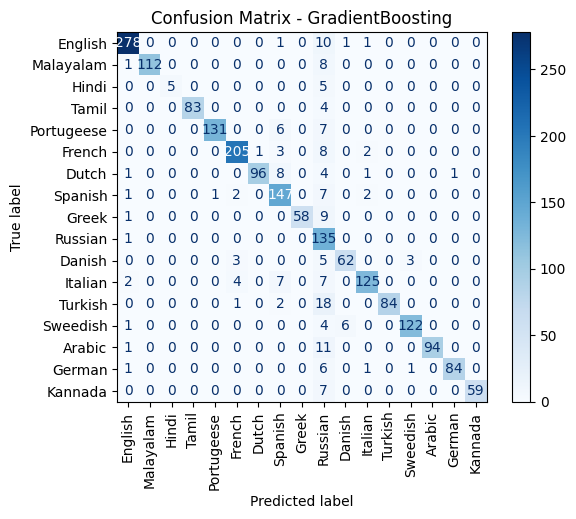


Confusion Matrix: SVM


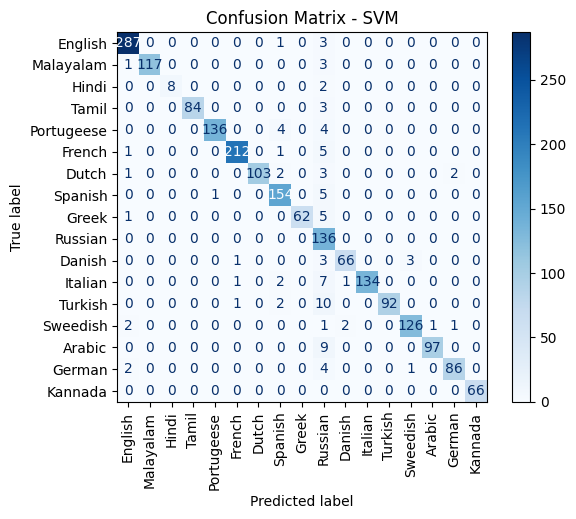


Confusion Matrix: MLPClassifier


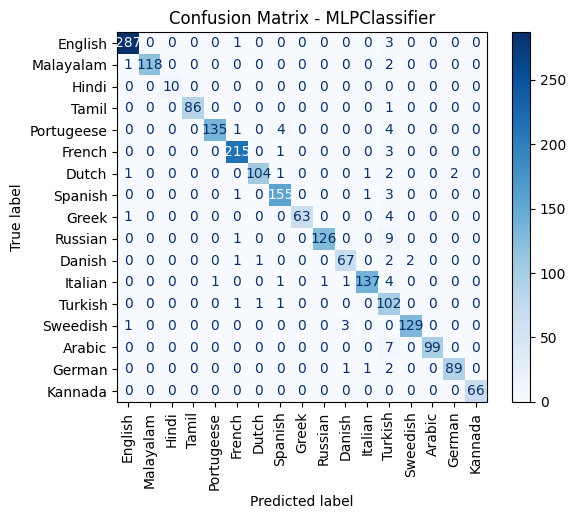

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function to plot confusion matrix for a given model
def plot_confusion_matrix(model_name, y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred, labels=data['Language'].unique())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data['Language'].unique())
    disp.plot(cmap='Blues', xticks_rotation=90)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# MultinomialNB
print("\nConfusion Matrix: MultinomialNB")
plot_confusion_matrix("MultinomialNB", y_test, y_pred_nb)

# LogisticRegression
print("\nConfusion Matrix: LogisticRegression")
plot_confusion_matrix("LogisticRegression", y_test, y_pred_lr)

# DecisionTree
print("\nConfusion Matrix: DecisionTree")
plot_confusion_matrix("DecisionTree", y_test, y_pred_dt)

# RandomForest
print("\nConfusion Matrix: RandomForest")
plot_confusion_matrix("RandomForest", y_test, y_pred_rf)

# GradientBoosting
print("\nConfusion Matrix: GradientBoosting")
plot_confusion_matrix("GradientBoosting", y_test, y_pred_gb)

# SVM
print("\nConfusion Matrix: SVM")
plot_confusion_matrix("SVM", y_test, y_pred_svm)

# MLPClassifier
print("\nConfusion Matrix: MLPClassifier")
plot_confusion_matrix("MLPClassifier", y_test, y_pred_mlp)


## Installing library for translation

In [28]:
!pip install langdetect textblob googletrans==4.0.0-rc1 nltk


## importing libraries

In [30]:

# Import the 'detect' function from langdetect to identify the language of a given text
from langdetect import detect

# Import DetectorFactory to set a seed for consistent language detection results
from langdetect import DetectorFactory

# Import TextBlob for text processing tasks like translation and sentiment analysis
from textblob import TextBlob

# Import Translator from googletrans for translating text between languages
from googletrans import Translator

# Import SentimentIntensityAnalyzer from nltk to analyze the sentiment of text (positive, negative, or neutral)
from nltk.sentiment import SentimentIntensityAnalyzer

# Import tkinter library for creating the graphical user interface (GUI)
import tkinter as tk

# Import ttk for enhanced widgets in the Tkinter library
from tkinter import ttk, Text, messagebox

# Set a fixed seed to ensure that the results of the language detection are consistent across runs
DetectorFactory.seed = 0

# Import nltk for natural language processing tasks
import nltk

# Download the 'vader_lexicon' data for sentiment analysis (required by SentimentIntensityAnalyzer)
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Mutahar\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Define Functions

In [32]:
# Cell 2: Define Functions

# Detect language of the given text
def detect_language(text):
    """
    Detects the language of a given text using the 'langdetect' library.

    Parameters:
    text (str): The text whose language is to be detected.

    Returns:
    str: The detected language in full form (e.g., "English", "French"). 
         If the language is not recognized, returns "Unknown".
         If an error occurs, returns the error message.
    """
    try:
        # Use langdetect to find the language code (e.g., "en" for English)
        lang_code = detect(text)
        
        # Mapping language codes to full language names
        languages = {
            "en": "English", "fr": "French", "es": "Spanish", "pt": "Portuguese", "it": "Italian",
            "ru": "Russian", "sv": "Swedish", "ml": "Malayalam", "nl": "Dutch", "ar": "Arabic",
            "tr": "Turkish", "de": "German", "ta": "Tamil", "da": "Danish", "kn": "Kannada",
            "el": "Greek", "hi": "Hindi"
        }
        
        # Return the language name based on the detected language code
        return languages.get(lang_code, "Unknown")
    except Exception as e:
        # Return error message if something goes wrong
        return f"Error: {e}"

# Translate text to a target language (default is English)
def translate_text(text, target_lang="en"):
    """
    Translates a given text into a specified target language using Google Translator.

    Parameters:
    text (str): The text to be translated.
    target_lang (str): The target language code (default is "en" for English).

    Returns:
    str: The translated text.
         If an error occurs, returns the error message.
    """
    try:
        # Create a Translator object
        translator = Translator()
        
        # Translate the text to the target language
        translation = translator.translate(text, dest=target_lang)
        
        # Return the translated text
        return translation.text
    except Exception as e:
        # Return error message if something goes wrong
        return f"Error: {e}"

# Perform sentiment analysis on the text
def analyze_sentiment(text):
    """
    Analyzes the sentiment of a given text using the 'nltk' SentimentIntensityAnalyzer.

    Parameters:
    text (str): The text whose sentiment is to be analyzed.

    Returns:
    str: The sentiment of the text ("Positive", "Negative", "Neutral").
         If an error occurs, returns the error message.
    """
    try:
        # Create a SentimentIntensityAnalyzer object
        sia = SentimentIntensityAnalyzer()
        
        # Get sentiment polarity scores
        sentiment = sia.polarity_scores(text)
        
        # Determine sentiment based on the compound score
        if sentiment["compound"] > 0:
            return "Positive"  # Positive sentiment
        elif sentiment["compound"] < 0:
            return "Negative"  # Negative sentiment
        else:
            return "Neutral"   # Neutral sentiment
    except Exception as e:
        # Return error message if something goes wrong
        return f"Error: {e}"


## GUI Code

In [55]:
# Importing necessary libraries for GUI
import tkinter as tk  # For creating the graphical user interface
from tkinter import Text, messagebox  # For text input and displaying error messages

# Initialize main window
root = tk.Tk()  # Creates the main application window
root.title("Language Detection & Analysis")  # Sets the title of the window
root.geometry("500x600")  # Sets the dimensions of the window

# Input Text Box
# Adding a label for the text input box
tk.Label(root, text="Enter Text:", font=("Arial", 12)).pack(pady=10)  # Adds a label above the input box

# Adding a text box where users can enter text for analysis
input_text = Text(root, wrap="word", height=10, font=("Arial", 12))  # Text box for user input
input_text.pack(padx=10, pady=5)  # Adds padding around the text box for better appearance

# Results Labels
# Creating labels to display results such as detected language, translation, and sentiment
detected_language_label = tk.Label(root, text="Detected Language: ", font=("Arial", 12))  # Label for detected language
detected_language_label.pack(pady=10)  # Adds vertical padding

translated_text_label = tk.Label(root, text="Translated Text: ", font=("Arial", 12))  # Label for translated text
translated_text_label.pack(pady=10)  # Adds vertical padding

sentiment_label = tk.Label(root, text="Sentiment: ", font=("Arial", 12))  # Label for sentiment analysis result
sentiment_label.pack(pady=10)  # Adds vertical padding

# Function to Process Text
def process_text():
    """
    Processes the text entered by the user:
    1. Detects the language.
    2. Translates the text into English.
    3. Analyzes the sentiment of the translated text.
    """
    # Get the text entered by the user
    text = input_text.get("1.0", tk.END).strip()  # Fetches all the text from the input box and removes extra spaces
    
    if not text:  # Checks if the text box is empty
        messagebox.showerror("Input Error", "Please enter some text.")  # Displays an error message
        return

    # Detect the language of the text
    detected_language = detect_language(text)  # Calls the detect_language function (defined separately)
    detected_language_label.config(text=f"Detected Language: {detected_language}")  # Updates the detected language label

    # Translate the text into English
    translated_text = translate_text(text)  # Calls the translate_text function (defined separately)
    translated_text_label.config(text=f"Translated Text: {translated_text}")  # Updates the translated text label

    # Analyze the sentiment of the translated text
    sentiment = analyze_sentiment(translated_text)  # Calls the analyze_sentiment function (defined separately)
    sentiment_label.config(text=f"Sentiment: {sentiment}")  # Updates the sentiment label

# Process Button
# Adding a button to trigger the text processing
process_button = tk.Button(root, text="Analyze", font=("Arial", 12), command=process_text)  # Button to analyze the input text
process_button.pack(pady=20)  # Adds vertical padding below the button

# Run GUI
root.mainloop()  # Starts the main GUI event loop, keeps the window open
